# Week 2 Jupyter Notebook
## Linear Regression

### Marketing Conversion Propensity Project

## Project Overview

The goal of this project is to identify which marketing and product performance variables are associated with stronger conversion outcomes. Understanding these relationships can help organizations improve marketing strategies, allocate resources more effectively, and increase overall campaign performance.

This Week 2 analysis focuses on regularized linear regression techniques, including Ridge Regression, Lasso Regression, and Elastic Net Regression. These methods help address issues such as overfitting and multicollinearity while improving model stability and predictive performance.

The target variable for this analysis is the number of conversions generated by a marketing campaign. Predictor variables include campaign budget, clicks, revenue generated, return on investment (ROI), subscription length, discount level, units sold, bundle price, and customer satisfaction measures.

The objective is to compare the performance of different regularization techniques and determine which model provides the most reliable predictions for marketing conversion outcomes.


In [3]:
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 41.5 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 54.7 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Load the dataset
df = pd.read_csv("marketing_and_product_performance.csv")

In [4]:
df.head()

,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


In [5]:
# Explore the dataset

print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

Dataset shape:
(10000, 17)

Column names:
Index(['Campaign_ID', 'Product_ID', 'Budget', 'Clicks', 'Conversions',
       'Revenue_Generated', 'ROI', 'Customer_ID', 'Subscription_Tier',
       'Subscription_Length', 'Flash_Sale_ID', 'Discount_Level', 'Units_Sold',
       'Bundle_ID', 'Bundle_Price', 'Customer_Satisfaction_Post_Refund',
       'Common_Keywords'],
      dtype='str')

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Campaign_ID                        10000 non-null  str    
 1   Product_ID                         10000 non-null  str    
 2   Budget                             10000 non-null  float64
 3   Clicks                             10000 non-null  int64  
 4   Conversions                        10000 non-null  int64  
 5   Revenue_Generated                  10000 non-n

In [6]:
df.isnull().sum()

Campaign_ID                          0
Product_ID                           0
Budget                               0
Clicks                               0
Conversions                          0
Revenue_Generated                    0
ROI                                  0
Customer_ID                          0
Subscription_Tier                    0
Subscription_Length                  0
Flash_Sale_ID                        0
Discount_Level                       0
Units_Sold                           0
Bundle_ID                            0
Bundle_Price                         0
Customer_Satisfaction_Post_Refund    0
Common_Keywords                      0
dtype: int64

In [7]:
# Drop missing values

df = df.dropna()

In [8]:
# Select features and target

features = [
    "Budget",
    "Clicks",
    "Revenue_Generated",
    "ROI",
    "Subscription_Length",
    "Discount_Level",
    "Units_Sold",
    "Bundle_Price",
    "Customer_Satisfaction_Post_Refund"
]

X = df[features]
y = df["Conversions"]

In [9]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [10]:
# Feature scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Baseline Linear Regression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

linear_pred = linear_model.predict(X_test_scaled)

linear_r2 = r2_score(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))

print("Linear Regression R2:", linear_r2)
print("Linear Regression RMSE:", linear_rmse)

Linear Regression R2: -0.0002424309712767414
Linear Regression RMSE: 290.9955380443076


In [12]:
# Ridge Regression

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

ridge_pred = ridge_model.predict(X_test_scaled)

ridge_r2 = r2_score(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

print("Ridge Regression R2:", ridge_r2)
print("Ridge Regression RMSE:", ridge_rmse)

Ridge Regression R2: -0.00024238572552892634
Ridge Regression RMSE: 290.99553146274775


In [13]:
# Lasso Regression

lasso_model = Lasso(alpha=0.1, max_iter=10000)

lasso_model.fit(X_train_scaled, y_train)

lasso_pred = lasso_model.predict(X_test_scaled)

lasso_r2 = r2_score(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))

print("Lasso Regression R2:", lasso_r2)
print("Lasso Regression RMSE:", lasso_rmse)

Lasso Regression R2: -0.0002440929796430069
Lasso Regression RMSE: 290.9957798041065


In [14]:
# Elastic Net Regression

elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)

elastic_model.fit(X_train_scaled, y_train)

elastic_pred = elastic_model.predict(X_test_scaled)

elastic_r2 = r2_score(y_test, elastic_pred)
elastic_rmse = np.sqrt(mean_squared_error(y_test, elastic_pred))

print("Elastic Net Regression R2:", elastic_r2)
print("Elastic Net Regression RMSE:", elastic_rmse)

Elastic Net Regression R2: -0.0002309798902326854
Elastic Net Regression RMSE: 290.99387233661344


In [15]:
# Compare model performance

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Elastic Net Regression"
    ],
    "R2 Score": [
        linear_r2,
        ridge_r2,
        lasso_r2,
        elastic_r2
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        elastic_rmse
    ]
})

results

,Model,R2 Score,RMSE
0,Linear Regression,-0.000242,290.995538
1,Ridge Regression,-0.000242,290.995531
2,Lasso Regression,-0.000244,290.995780
3,Elastic Net Regression,-0.000231,290.993872


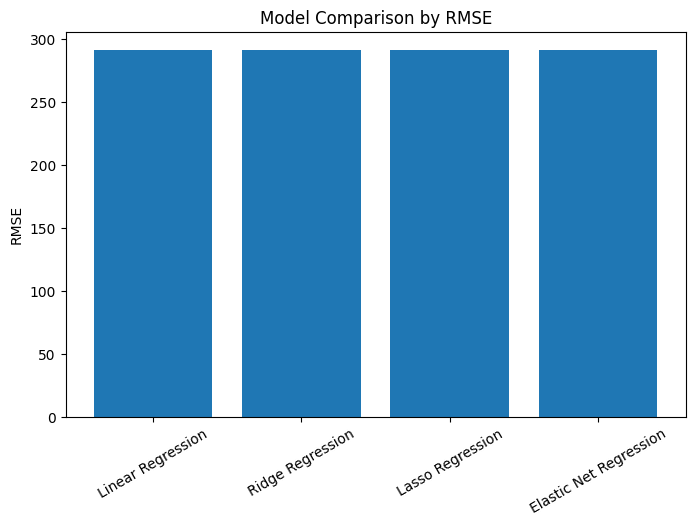

In [16]:
# Plot RMSE comparison

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["RMSE"])

plt.ylabel("RMSE")
plt.title("Model Comparison by RMSE")
plt.xticks(rotation=30)

plt.show()

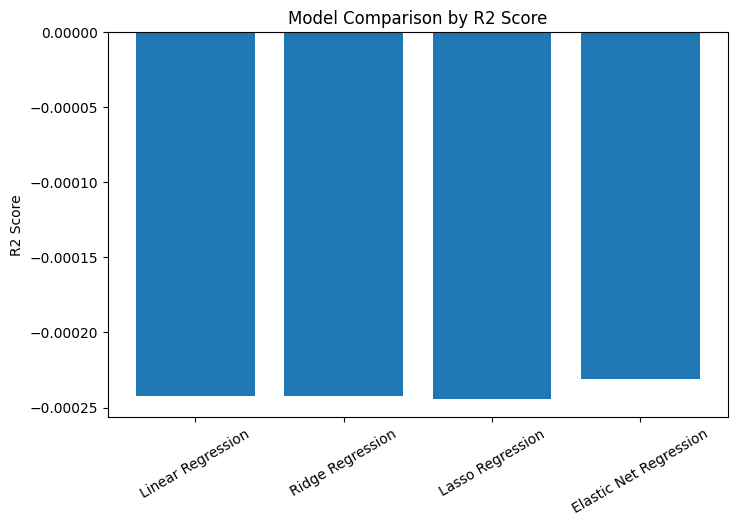

In [17]:
# Plot R2 comparison

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R2 Score"])

plt.ylabel("R2 Score")
plt.title("Model Comparison by R2 Score")
plt.xticks(rotation=30)

plt.show()

In [18]:
# Compare coefficients

coef_df = pd.DataFrame({
    "Feature": features,
    "Linear Regression": linear_model.coef_,
    "Ridge Regression": ridge_model.coef_,
    "Lasso Regression": lasso_model.coef_,
    "Elastic Net Regression": elastic_model.coef_
})

coef_df

,Feature,Linear Regression,Ridge Regression,Lasso Regression,Elastic Net Regression
0,Budget,-5.906692,-5.905944,-5.805362,-5.573652
1,Clicks,4.155574,4.155062,4.055589,3.912731
2,Revenue_Generated,-0.883415,-0.883288,-0.781526,-0.786687
3,ROI,-1.383758,-1.383594,-1.283902,-1.273619
4,Subscription_Length,1.428019,1.427846,1.325820,1.313266
5,Discount_Level,-5.674834,-5.674120,-5.576204,-5.355967
6,Units_Sold,3.932649,3.932148,3.829355,3.692645
7,Bundle_Price,-5.012246,-5.011631,-4.916496,-4.732024
8,Customer_Satisfaction_Post_Refund,1.607217,1.607033,1.508987,1.489892


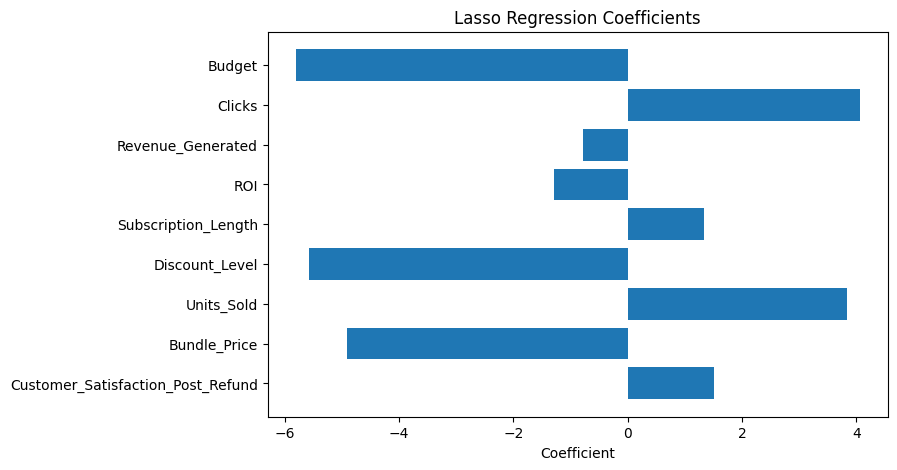

In [19]:
# Plot Lasso coefficients

plt.figure(figsize=(8,5))

plt.barh(coef_df["Feature"], coef_df["Lasso Regression"])

plt.xlabel("Coefficient")
plt.title("Lasso Regression Coefficients")
plt.gca().invert_yaxis()

plt.show()

In [20]:
# Try different alpha values for Ridge

alphas = [0.01, 0.1, 1, 10, 100]

ridge_scores = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    ridge_scores.append([alpha, r2, rmse])

ridge_results = pd.DataFrame(
    ridge_scores,
    columns=["Alpha", "R2 Score", "RMSE"]
)

ridge_results

,Alpha,R2 Score,RMSE
0,0.01,-0.000242,290.995538
1,0.10,-0.000242,290.995537
2,1.00,-0.000242,290.995531
3,10.00,-0.000242,290.995473
4,100.00,-0.000238,290.994923


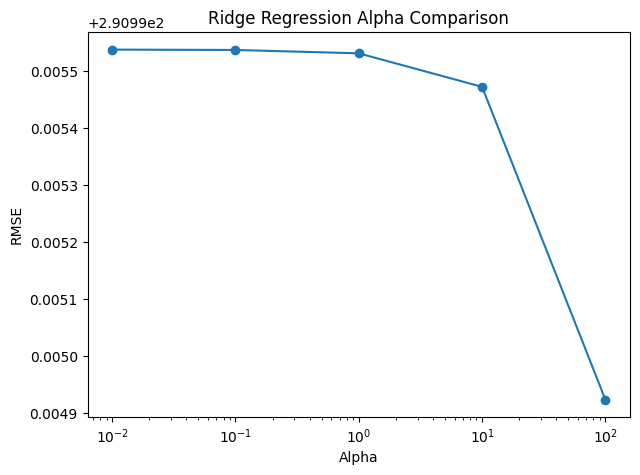

In [21]:
# Plot Ridge alpha comparison

plt.figure(figsize=(7,5))

plt.plot(ridge_results["Alpha"], ridge_results["RMSE"], marker="o")

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.title("Ridge Regression Alpha Comparison")

plt.show()

In [22]:
# Try different alpha values for Lasso

lasso_scores = []

for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    lasso_scores.append([alpha, r2, rmse])

lasso_results = pd.DataFrame(
    lasso_scores,
    columns=["Alpha", "R2 Score", "RMSE"]
)

lasso_results

,Alpha,R2 Score,RMSE
0,0.01,-0.000242,290.995548
1,0.10,-0.000244,290.995780
2,1.00,-0.000377,291.015070
3,10.00,-0.001490,291.176919
4,100.00,-0.001490,291.176919


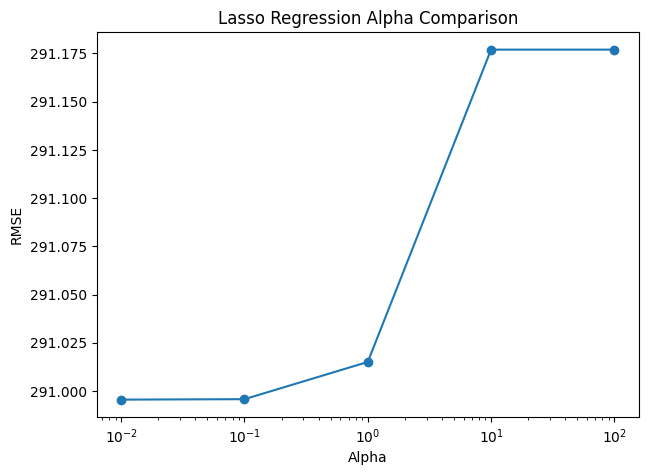

In [23]:
# Plot Lasso alpha comparison

plt.figure(figsize=(7,5))

plt.plot(lasso_results["Alpha"], lasso_results["RMSE"], marker="o")

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.title("Lasso Regression Alpha Comparison")

plt.show()

# Conclusion

This Week 2 notebook applied regularized linear regression methods to the Marketing Conversion Propensity dataset. The target variable was Conversions, and the predictor variables included Budget, Clicks, Revenue_Generated, ROI, Subscription_Length, Discount_Level, Units_Sold, Bundle_Price, and Customer_Satisfaction_Post_Refund.

A baseline Linear Regression model was first created, followed by Ridge Regression, Lasso Regression, and Elastic Net Regression. Ridge Regression helps reduce overfitting by shrinking coefficients. Lasso Regression can shrink some coefficients to zero, making it useful for feature selection. Elastic Net combines Ridge and Lasso penalties.

The models were compared using R2 Score and RMSE. R2 measures how much variation in conversions is explained by the model, while RMSE measures the average prediction error. The alpha comparison helped show how stronger or weaker regularization affects model performance.

Overall, this analysis supports the capstone project by showing how regularized regression techniques can be used to predict marketing conversions and understand which campaign variables contribute most to conversion outcomes.